In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Stripmap SAR Survey of a Few Houses

This notebook extends the companion [waveform_lfm_sar.ipynb](waveform_lfm_sar.ipynb) notebook — same C-band LFM chirp waveform, same stretch/deramp receiver model, same Back-Projection (BPA) focusing — but replaces the three idealized point targets with a **small synthetic scene: four simple houses standing on an exactly flat plot of ground**. Everything here happens at close range (altitude and standoff measured in tens of meters, not kilometers) — a slow drone flyover imaging a handful of buildings, not a survey aircraft mapping terrain.

Flying a synthetic side-looking radar over discrete 3-D structures — rather than isolated point scatterers on a flat plane, or continuously-varying terrain — exposes **relief displacement (layover)** in its cleanest possible form. The ground truth here is *exactly* flat (`z = 0` everywhere except inside a house footprint), so Back-Projection's flat-earth reference `z_ref` is not an approximation — it's exact for the ground. Any layover we see is caused **purely by the houses themselves**: each one rises above `z_ref`, so its roof returns energy at a shorter range than a ground pixel at the same map coordinate would, and Back-Projection places that energy too close to the radar. This is exactly why real airborne and spaceborne SAR images of neighborhoods show buildings "leaning" toward the sensor, and it's the central lesson of this notebook.

## What's different from the point-target notebook

| | `waveform_lfm_sar.ipynb` | This notebook |
|---|---|---|
| Target | 3 ideal point scatterers | 4 synthetic houses + a flat ground plane, ray-traced |
| Scene relief | Flat, z = 0 everywhere | Flat ground (`z_ref` exact) + 5 m house structures |
| Geometry | Flat 2-D (broadside, no altitude) | Full 3-D side-looking stripmap (altitude + depression angle) |
| Key artifact | None (ideal focusing) | Layover / relief displacement — isolated to the buildings |
| Antenna | Wide azimuth, narrow elevation (flat scene) | Narrow azimuth (real 0.75 m aperture), **wide elevation** (must span the swath's depression-angle spread) |
| Scale | — | Tens of meters (slow low-altitude flyover), not kilometers |

## Workflow

```
Define the house/ground scene → LFM waveform + side-looking flight geometry
    → Transmitter / Receiver → sim_radar() over the houses + ground
    → Range Compression (fast-time FFT) → Back-Projection → SAR image
    → Compare true (analytic) scene height vs. imaged position (layover check)
```

## Setup

In [2]:
import time
import numpy as np
import scipy
from scipy import constants
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
import pymeshlab
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

## Scene Setup: A Few Houses on Flat Ground

Instead of scouting a large terrain model for an interesting corridor, we build the scene ourselves: a single reusable house mesh (`house.stl` — a simple gable-roofed box, watertight, 8 m × 10 m footprint, 5.0 m ridge height) instantiated at four locations over a flat 60 m × 60 m ground plane (`surface_60x60.stl`). Because the houses are simple parametric boxes-with-a-roof, we also have an **exact analytic formula** for the true scene height at any (x, y) — no mesh sampling or interpolation needed for the "ground truth" comparisons later in the notebook.

House model: 8 m x 10 m footprint, eave 3.2 m, ridge 5.0 m
4 houses placed on a flat 60 m x 60 m ground plane:
  House 1: x=-20.0 m, y=-12.0 m
  House 2: x=-4.0 m, y=+10.0 m
  House 3: x=+14.0 m, y=-14.0 m
  House 4: x=+20.0 m, y=+8.0 m


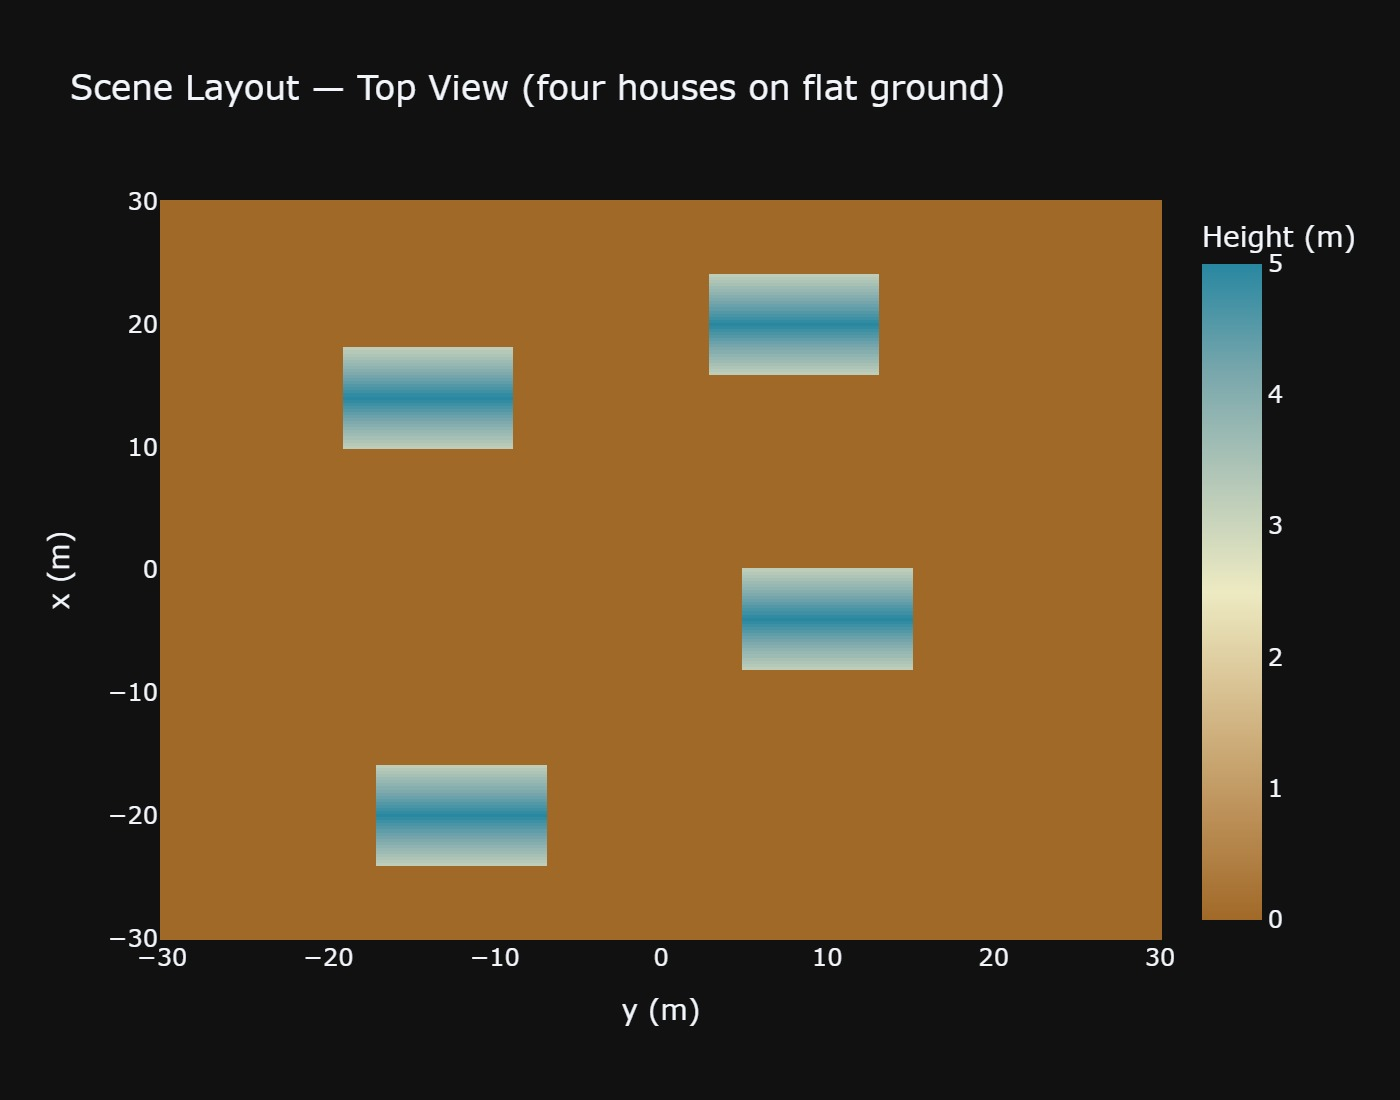

In [3]:
# -- House geometry (must match models/house.stl exactly) ---------------------------
HOUSE_W = 8.0  # footprint width, across the roof slope (m)
HOUSE_L = 10.0  # footprint length, along the ridge (m)
HOUSE_HW = 3.2  # wall (eave) height (m)
HOUSE_HR = 1.8  # additional rise from eave to ridge (m)
HOUSE_H = HOUSE_HW + HOUSE_HR  # total ridge height (m)

# -- Scene layout: four houses scattered over the flat 60x60 m ground plane ---------
house_positions = [(-20.0, -12.0), (-4.0, 10.0), (14.0, -14.0), (20.0, 8.0)]

print(f"House model: {HOUSE_W:.0f} m x {HOUSE_L:.0f} m footprint, "
      f"eave {HOUSE_HW:.1f} m, ridge {HOUSE_H:.1f} m")
print(f"{len(house_positions)} houses placed on a flat 60 m x 60 m ground plane:")
for i, (hx, hy) in enumerate(house_positions):
    print(f"  House {i+1}: x={hx:+.1f} m, y={hy:+.1f} m")


def scene_height(x, y):
    """Exact analytic true-height field for the house/ground scene (matches house.stl)."""
    z = np.zeros_like(np.asarray(x, dtype=float))
    for hx, hy in house_positions:
        dx = np.abs(x - hx)
        dy = np.abs(y - hy)
        within = (dx <= HOUSE_W / 2) & (dy <= HOUSE_L / 2)
        roof_z = HOUSE_HW + HOUSE_HR * (1 - 2 * dx / HOUSE_W)
        z = np.where(within, np.maximum(z, roof_z), z)
    return z


# -- Preview the layout from directly above ------------------------------------------
xg = np.linspace(-30, 30, 241)
yg = np.linspace(-30, 30, 241)
XG, YG = np.meshgrid(xg, yg, indexing="ij")
ZG = scene_height(XG, YG)

fig = go.Figure(
    go.Heatmap(
        x=yg, y=xg, z=ZG,
        colorscale="Earth",
        colorbar=dict(title="Height (m)"),
    )
)
fig.update_layout(
    title="Scene Layout — Top View (four houses on flat ground)",
    xaxis_title="y (m)",
    yaxis_title="x (m)",
    template="plotly_dark",
    height=550,
)
show(fig)

### Imaging Window

The imaging swath is centred on the house cluster, with enough margin on all sides to keep every house comfortably inside the focused image.

| Parameter | Value |
|---|---|
| Azimuth (along-track) reference `cx` | 0.0 m |
| Cross-track survey swath `y` | -25.0 – 25.0 m |
| Scene height range | 0 (ground, exact) – 5.0 m (house ridges) |

In [4]:
cx = 0.0
y0, y1 = -25.0, 25.0

print(f"Cross-track swath: y = {y0:.1f} to {y1:.1f} m")
for i, (hx, hy) in enumerate(house_positions):
    print(f"  House {i+1} (x={hx:+.1f}, y={hy:+.1f}): inside swath = {y0 <= hy <= y1}")

Cross-track swath: y = -25.0 to 25.0 m
  House 1 (x=-20.0, y=-12.0): inside swath = True
  House 2 (x=-4.0, y=+10.0): inside swath = True
  House 3 (x=+14.0, y=-14.0): inside swath = True
  House 4 (x=+20.0, y=+8.0): inside swath = True


### Waveform, Flight Geometry & Sampling Parameters

Same **C-band LFM chirp** family as the point-target notebook (`fc` = 4 GHz), with **B = 800 MHz** (→ ΔR = 0.187 m, a 20% fractional bandwidth) and a **short 2 μs pulse** — this scene's slant ranges are only ~160-210 m, so there's no need to stretch the chirp to tame the sample rate; `fs` stays around 1.3 GHz.

This is also genuinely a **3-D side-looking stripmap** geometry: the platform flies at altitude with a lateral standoff from the swath, so every pixel has both a cross-track ground distance *and* a vertical offset — unlike the flat, altitude-free 2-D geometry in the point-target notebook. The platform is modelled as a slow-flying survey UAS, and everything — altitude, standoff, flight length — is scaled to tens of meters, not kilometers: this is a close-in flyover of a handful of houses, not a mapping mission.

> **Depression angle drives how strongly the houses actually reflect, not just how cleanly layover shows up.** A simple flat-faced building model like the one here doesn't scatter equally in every direction: a single-bounce return off a vertical wall or a sloped roof is a *specular* reflection, only strong when the radar's line of sight is close to that surface's mirror direction, and it mostly relies on a **wall-ground double bounce** (the classic dihedral "corner reflector" effect that makes real buildings so bright in urban SAR) rather than a single wall or roof reflection. That double-bounce return is strongest at **shallow** depression angles and falls off quickly past about 25° — the opposite intuition from "steeper must mean a better look." A shallow ≈14-18° depression here keeps the houses solidly above the noise floor and, as a bonus, is nowhere near steep enough to risk near-nadir layover fold-over given the houses' modest 5 m height.
>
> **The ground truth here is exactly flat.** Unlike a real DEM (or the previous version of this notebook, which used natural terrain), `z_ref` is set to the scene's *actual* ground elevation, 0 m — not an estimate. That means Back-Projection focuses the bare ground perfectly; every bit of layover visible in the final image comes from the houses themselves standing above that exact reference.
>
> **Proper stripmap focusing: a sliding aperture, not one global sum.** Earlier passes through this notebook family summed the *entire* flight as one synthetic aperture for every pixel (spotlight-style), which forced pulse count to scale with the *square* of the aperture length. Real stripmap SAR doesn't do that: a ground point is only ever illuminated while it sits inside the antenna's **real-beam footprint** (length ≈ Rλ/Dₐ), so each pixel only needs the pulses from *its own* local dwell — a sliding window, not the whole flight. PRF only needs to satisfy the *local* Nyquist criterion `PRF > 2v/Dₐ`, so pulse count now grows only linearly with swath length. The trade-off: azimuth resolution is fixed at the real-aperture limit `Δaz = Dₐ/2` everywhere (0.375 m for our 0.75 m antenna) — counterintuitively, a *smaller* antenna gives a *finer* stripmap resolution, because its wider real beam keeps a ground point illuminated over a longer dwell. Coarser than a spotlight-style number would report, but the physically honest value — and still fine enough to separate houses that are tens of meters apart.
>
> **PRF is oversampled well above Nyquist.** `Δaz = Dₐ/2` is a real-aperture limit set purely by antenna size — it does **not** improve with more pulses, so pushing PRF higher can't sharpen the image past that floor. What extra pulses *do* buy: with `prf_margin = 4.0` (4x the strict Nyquist minimum), each pixel sits inside the real-beam footprint for many more pulses, giving more independent coherent looks across its dwell (better speckle averaging) and a more finely-sampled raised-cosine taper (lower azimuth sidelobes). Getting resolution finer than `Dₐ/2` for real would require spotlight-mode beam-steering to extend the dwell beyond the natural footprint — which is exactly the aperture-squared-cost approach this notebook moved away from.
>
> **A second, independent limit: simulated flight duration.** This evaluation build of `sim_radar` also silently stops updating platform motion once the simulated timeline exceeds ≈5.0 seconds — pulses beyond that point quietly return stale, bit-for-bit identical data instead of erroring. Capping any single call's duration at 4.0 s (a safety margin) avoids it.
>
> **Chaining calls to get past both limits at once.** Neither limit is about total flight length — they're both per-call. So instead of one `sim_radar` call, this notebook makes several, each with its own fresh `radar.set_motion(...)` continuing on from where the last segment left off, each safely under 4.0 s / `num_pulses` pulses. The range-compressed results are concatenated afterward and back-projected as a single combined pulse train, giving a total flight several times longer than any single call could produce.

In [5]:
c = constants.c  # Speed of light (m/s)

# Carrier / LFM waveform
fc = 4e9  # Carrier frequency (Hz) - C-band
lam = c / fc  # Wavelength (m)
bw = 800e6  # LFM sweep bandwidth (Hz)  ->  dR = c/(2B) = 0.187 m  (20% fractional BW)
tpd = 2e-6  # Chirp (pulse) duration (s) - short; ranges here are only ~160-210 m
tx_power_dbm = 40  # Transmit power (dBm)

# Platform / flight-line geometry
Da = 0.75  # Real antenna azimuth dimension (m) - smaller aperture -> finer stripmap az resolution
v_platform = 5.0  # Along-track velocity (m/s) - slow-flying survey UAS
y_fly = -180.0  # Flight line cross-track position (m) - standoff from the swath
z_fly = 50.0  # Flight altitude (m) - a slow, low flyover, not a mapping mission
z_ref = 0.0  # Flat-earth reference elevation assumed by Back-Projection (m) - EXACT ground truth here

ymid = (y0 + y1) / 2
dep_center = np.degrees(np.arctan2(z_fly - z_ref, ymid - y_fly))
dep_near = np.degrees(np.arctan2(z_fly - z_ref, y0 - y_fly))
dep_far = np.degrees(np.arctan2(z_fly - z_ref, y1 - y_fly))
R_near = np.hypot(y0 - y_fly, z_fly - z_ref)
R_far = np.hypot(y1 - y_fly, z_fly - z_ref)
R_mid = (R_near + R_far) / 2

# -- Azimuth sampling: proper stripmap (sliding-window) criterion -------------------
# Unlike a global spotlight-style sum, each pixel here is only focused from pulses
# within its own local real-beam footprint, so PRF only needs to satisfy the LOCAL
# Nyquist criterion (independent of total flight length) -- not the aperture-squared
# criterion the earlier spotlight-style version needed. NOTE: azimuth RESOLUTION is
# fixed at Da/2 regardless of PRF -- it's a real-aperture limit, not a sampling limit.
# Oversampling well above the strict Nyquist minimum doesn't sharpen the image, but it
# does give each pixel more independent looks across its dwell (better multi-look
# speckle averaging) and a more finely-sampled raised-cosine taper (lower sidelobes).
prf_margin = 4.0  # oversampling factor above the strict Nyquist limit
prf = prf_margin * 2 * v_platform / Da

# -- Per-call duration is capped ----------------------------------------------------
# This evaluation build of sim_radar silently STOPS updating platform motion after
# ~5.0 s of simulated time (verified empirically: pulses beyond that point return
# bit-for-bit identical baseband regardless of true position). There's no error --
# it just quietly re-reports stale data, which back-projection then coherently
# smears across the image. Capping each CALL's duration well under that threshold
# avoids it; chaining several such calls (below) reaches a much longer total flight.
max_duration_s = 4.0  # safety margin below the ~5.0 s observed failure point
pulse_cap = 1650  # separate, independent licensed ceiling on pulses-per-call
num_pulses = min(pulse_cap, int(prf * max_duration_s))  # pulses PER segment/call
prp = 1 / prf  # Pulse repetition period (s)
synthetic_aperture = v_platform * num_pulses / prf  # flight length PER segment (m)
actual_duration_s = num_pulses / prf

# -- Chain several such calls end-to-end to reach a much longer total flight -------
n_segments = 3
total_flight_length = n_segments * synthetic_aperture

# Real-beam footprint: the ground length illuminated by the antenna at any instant.
# Each pixel is focused only from pulses while it sits inside this footprint.
footprint_length = R_mid * lam / Da
az_res_stripmap = Da / 2  # real-aperture-limited azimuth resolution (fixed, not aperture-dependent)
pulses_per_dwell = prf * footprint_length / v_platform  # independent looks contributing to each pixel

# Derived waveform quantities
range_res = c / (2 * bw)
bt_product = bw * tpd  # Time-bandwidth product
mf_gain_db = 10 * np.log10(bt_product)  # Matched-filter / pulse-compression gain

# Sample rate: must satisfy fs > 4*R_max*B/(c*tau) to avoid beat-frequency aliasing
fs_min = 4 * (R_far + 15) * bw / (c * tpd)
fs = 1300e6  # Chosen with margin above fs_min
pulse_samples = int(tpd * fs)  # Fast-time samples per pulse (dechirped beat-tone record)

print(f"fc={fc/1e9:.0f} GHz  B={bw/1e6:.0f} MHz  tau={tpd*1e6:.1f} us")
print(f"dR={range_res:.3f} m   B*tau={bt_product:.0f}   MF gain={mf_gain_db:.1f} dB")
print(f"fs_min={fs_min/1e6:.1f} MHz  ->  fs={fs/1e6:.0f} MHz  ({pulse_samples} samples/pulse)")
print(f"Flight altitude z={z_fly:.0f} m, standoff y_fly={y_fly:.0f} m, flat-earth reference z_ref={z_ref:.0f} m")
print(f"Depression angle: near={dep_near:.1f} deg  centre={dep_center:.1f} deg  far={dep_far:.1f} deg")
print(f"Slant range: near={R_near:.1f} m  far={R_far:.1f} m  mid={R_mid:.1f} m")
print(f"PRF={prf:.2f} Hz ({prf_margin:.1f}x Nyquist)  ->  num_pulses/segment={num_pulses}  "
      f"(duration-capped: {actual_duration_s:.2f} s vs {max_duration_s:.1f} s limit; pulse cap was {pulse_cap})")
print(f"Per-segment flight length: {synthetic_aperture:.1f} m")
print(f"Chaining {n_segments} segments -> total flight length: {total_flight_length:.1f} m "
      f"({n_segments * num_pulses} pulses total)")
print(f"Real-beam footprint (per-pixel dwell): {footprint_length:.2f} m  ->  daz(stripmap) = {az_res_stripmap:.3f} m "
      f"({pulses_per_dwell:.0f} pulses illuminate each pixel)")

fc=4 GHz  B=800 MHz  tau=2.0 us
dR=0.187 m   B*tau=1600   MF gain=32.0 dB
fs_min=1206.2 MHz  ->  fs=1300 MHz  (2600 samples/pulse)
Flight altitude z=50 m, standoff y_fly=-180 m, flat-earth reference z_ref=0 m
Depression angle: near=17.9 deg  centre=15.5 deg  far=13.7 deg
Slant range: near=162.9 m  far=211.0 m  mid=186.9 m
PRF=53.33 Hz (4.0x Nyquist)  ->  num_pulses/segment=213  (duration-capped: 3.99 s vs 4.0 s limit; pulse cap was 1650)
Per-segment flight length: 20.0 m
Chaining 3 segments -> total flight length: 59.9 m (639 pulses total)
Real-beam footprint (per-pixel dwell): 18.68 m  ->  daz(stripmap) = 0.375 m (199 pulses illuminate each pixel)


### Transmitter, Receiver & Antenna

The antenna design flips the emphasis from the point-target notebook. There, azimuth needed a wide beam to keep small, isolated targets illuminated across the whole synthetic aperture, while elevation could stay narrow (the scene was flat). Here:

- **Azimuth** is realistically **narrow** — a 0.75 m antenna at 4 GHz has a natural (3 dB) beamwidth of ≈5.7°, which is *exactly* what defines the real-beam footprint each pixel is focused from in stripmap mode. The pattern below is defined out to ±15° for a bit of margin past the 3 dB point.
- **Elevation** must be **wide** — the swath's depression angle spans ≈17.9° (near) down to ≈13.7° (far) around a ≈15.5° boresight, so the beam has to stay reasonably flat across ±20° around boresight.

The receiver samples at `fs` = 1.3 GHz, sized above by the requirement to keep the absolute-range beat frequency unambiguous out to the far edge of the swath.

In [6]:
# -- Antenna pattern --------------------------------------------------------
antenna_gain = 20  # dBi

# Azimuth: realistically narrow -- the cos^n exponent is DERIVED so the pattern's
# actual -3 dB half-angle matches lam/(2*Da), the physical beamwidth the real-beam
# footprint formula (footprint_length = R*lam/Da) assumes. A too-gentle exponent here
# would let the antenna illuminate targets far outside their real dwell, breaking the
# sliding-window BPA's assumption that each pixel is only seen from nearby pulses.
az_beamwidth_half_rad = lam / (2 * Da)
az_n = -3 / (20 * np.log10(np.cos(az_beamwidth_half_rad)))
az_angle = np.arange(-15, 16, 1)
az_pattern = 20 * az_n * np.log10(np.abs(np.cos(az_angle / 180 * np.pi))) + antenna_gain

# Elevation: wide -- must stay reasonably flat across the swath's depression-angle spread
el_angle = np.arange(-20, 21, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 3) + antenna_gain

tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

# -- LFM chirp waveform: f sweeps [fc-B/2, fc+B/2] over t=[0, tau]; idle for the rest of the PRP
tx = Transmitter(
    f=[fc - bw / 2, fc + bw / 2],
    t=[0, tpd],
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    prp=prp,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Chirp: {(fc-bw/2)/1e9:.4f} -> {(fc+bw/2)/1e9:.4f} GHz over {tpd*1e6:.1f} us")
print(f"  Duty cycle: {tpd/prp*100:.2f}%")
print(f"  Azimuth pattern: cos^{az_n:.0f}, actual -3dB half-angle = "
      f"{np.degrees(az_beamwidth_half_rad):.2f} deg")

Transmitter configured.
  Chirp: 3.6000 -> 4.4000 GHz over 2.0 us
  Duty cycle: 0.01%
  Azimuth pattern: cos^277, actual -3dB half-angle = 2.86 deg


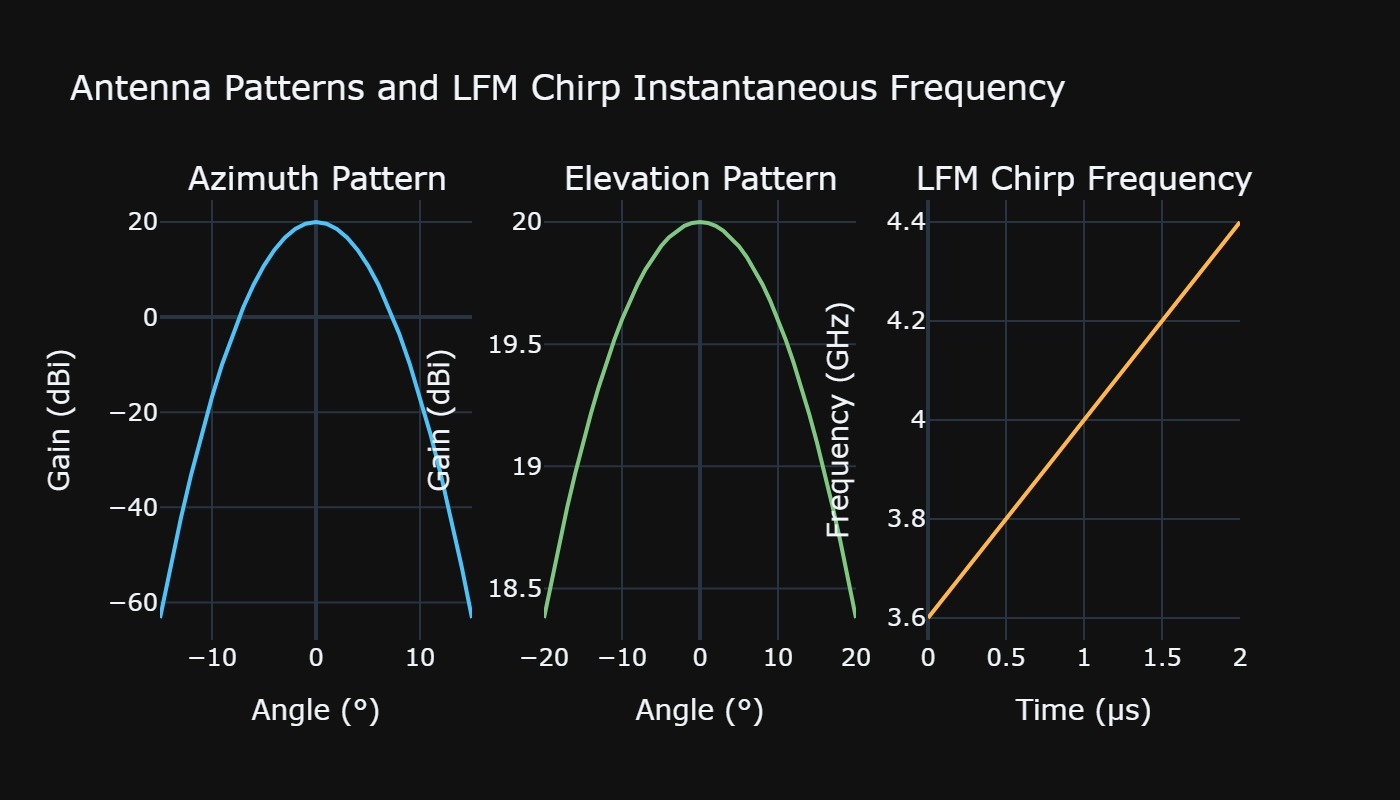

In [7]:
t_chirp = np.linspace(0, tpd, 500)
inst_freq_ghz = (fc + (bw / tpd) * (t_chirp - tpd / 2)) / 1e9  # instantaneous frequency

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Azimuth Pattern", "Elevation Pattern", "LFM Chirp Frequency"),
)

fig.add_trace(
    go.Scatter(x=az_angle, y=az_pattern, line=dict(color="#4FC3F7", width=2)),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=el_angle, y=el_pattern, line=dict(color="#81C784", width=2)),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=t_chirp * 1e6,
        y=inst_freq_ghz,
        line=dict(color="#FFB74D", width=2),
    ),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=2)
fig.update_yaxes(title_text="Frequency (GHz)", row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and LFM Chirp Instantaneous Frequency",
    template="plotly_dark",
    height=400,
    showlegend=False,
)
show(fig)

In [8]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,  # NF = 5 dB
    rf_gain=20,  # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate      : {fs/1e6:.0f} MHz")
print(f"  Samples per pulse: {pulse_samples}")

Receiver configured.
  Sample rate      : 1300 MHz
  Samples per pulse: 2600


### Platform Trajectory & Scene

The platform flies straight and level along **+x** at 5 m/s (a slow-flying survey UAS), offset **180 m in cross-track** from the swath (so standoff to the near/far edges is 155-205 m) and **50 m above the ground** — a genuinely close-in, low, slow flyover. That standoff keeps the depression angle shallow, which here is doing double duty: it avoids near-nadir layover fold-over *and* it's what makes the houses' wall-ground double-bounce return strong enough to see (see the callout above). The antenna boresight is yawed 90° to look broadside (+y) and pitched down by the ≈15.5° centre depression angle.

The flight is split into `n_segments` back-to-back stretches, each independently under the duration/pulse-count limits described above, with the next segment's platform positions picking up exactly where the previous one left off:

| Parameter | Value |
|---|---|
| Per-segment flight | ≈20 m flown, ≈4.0 s duration, PRF≈53.3 Hz (4x Nyquist), 213 pulses |
| Chained flight | 3 segments -> x ∈ [cx−30, cx+30] m (≈60 m total), y = -180 m, z = 50 m |
| Depression angle | ≈17.9° (near) → ≈15.5° (centre) → ≈13.7° (far) |
| Reference elevation `z_ref` | 0 m — the scene's **actual, exact** ground elevation |

Unlike the point-target notebook's three isolated scatterers, the "target" here is a small, discrete scene: a flat ground plane plus four house meshes, each contributing its own return.

In [9]:
# Platform flies along +x. Precompute the FULL, multi-segment flight path now (pure
# geometry -- no simulation needed yet) so it can be visualised before we get to the
# expensive part, and reused later to set each segment's motion during simulation.
segment_centers = cx - total_flight_length / 2 + synthetic_aperture * (np.arange(n_segments) + 0.5)

pulse_times = np.arange(num_pulses) * prp
pulse_times -= pulse_times.mean()

platform_x = np.concatenate([seg_center + v_platform * pulse_times for seg_center in segment_centers])
num_pulses_total = len(platform_x)

print(f"Chaining {n_segments} segments x {num_pulses} pulses = {num_pulses_total} pulses total")
print(f"Segment centres (x): {np.array2string(segment_centers, precision=1)}")
print(f"Full flight span: x = {platform_x.min():.1f} to {platform_x.max():.1f} m "
      f"({platform_x.max()-platform_x.min():.1f} m)")

Chaining 3 segments x 213 pulses = 639 pulses total
Segment centres (x): [-20.   0.  20.]
Full flight span: x = -29.9 to 29.9 m (59.8 m)


In [10]:
radar = Radar(
    transmitter=tx,
    receiver=rx,
)

# Motion is NOT set here -- each segment gets its own radar.set_motion(...) call during
# simulation (below), reusing this same Radar object with a fresh set of positions.

print(f"Radar created. {n_segments} segments x {num_pulses} pulses each = {num_pulses_total} pulses total.")
print(f"  Platform y={y_fly:.0f} m, z={z_fly:.0f} m")
print(f"  Boresight: yaw=90 deg (+y broadside), pitch={-dep_center:.1f} deg (elevation tilt)")

Radar created. 3 segments x 213 pulses each = 639 pulses total.
  Platform y=-180 m, z=50 m
  Boresight: yaw=90 deg (+y broadside), pitch=-15.5 deg (elevation tilt)


In [11]:
ground_target = {
    "model": "../models/surface_60x60.stl",  # flat 60 m x 60 m ground plane, centred at origin
    "location": (0, 0, 0),
    "speed": (0, 0, 0),
    "permittivity": 3.2 + 0.1j,  # soil/grass-like dielectric
    "skip_diffusion": True,  # large flat reflector -- specular only, keeps runtime down
    "environment": True,  # large surrounding surface -- reduced ray density
}

house_targets = [
    {
        "model": "../models/house.stl",
        "location": (hx, hy, 0),
        "speed": (0, 0, 0),
        "permittivity": 5,  # generic masonry/concrete
    }
    for hx, hy in house_positions
]

targets = [ground_target] + house_targets

print(f"Target: 1 ground plane (60 m x 60 m) + {len(house_targets)} houses")
print(f"  Illuminated swath: y = {y0:.0f} to {y1:.0f} m (cross-track)")
print(f"  Scene height: 0 m (ground, exact) to {HOUSE_H:.1f} m (house ridges)")

Target: 1 ground plane (60 m x 60 m) + 4 houses
  Illuminated swath: y = -25 to 25 m (cross-track)
  Scene height: 0 m (ground, exact) to 5.0 m (house ridges)


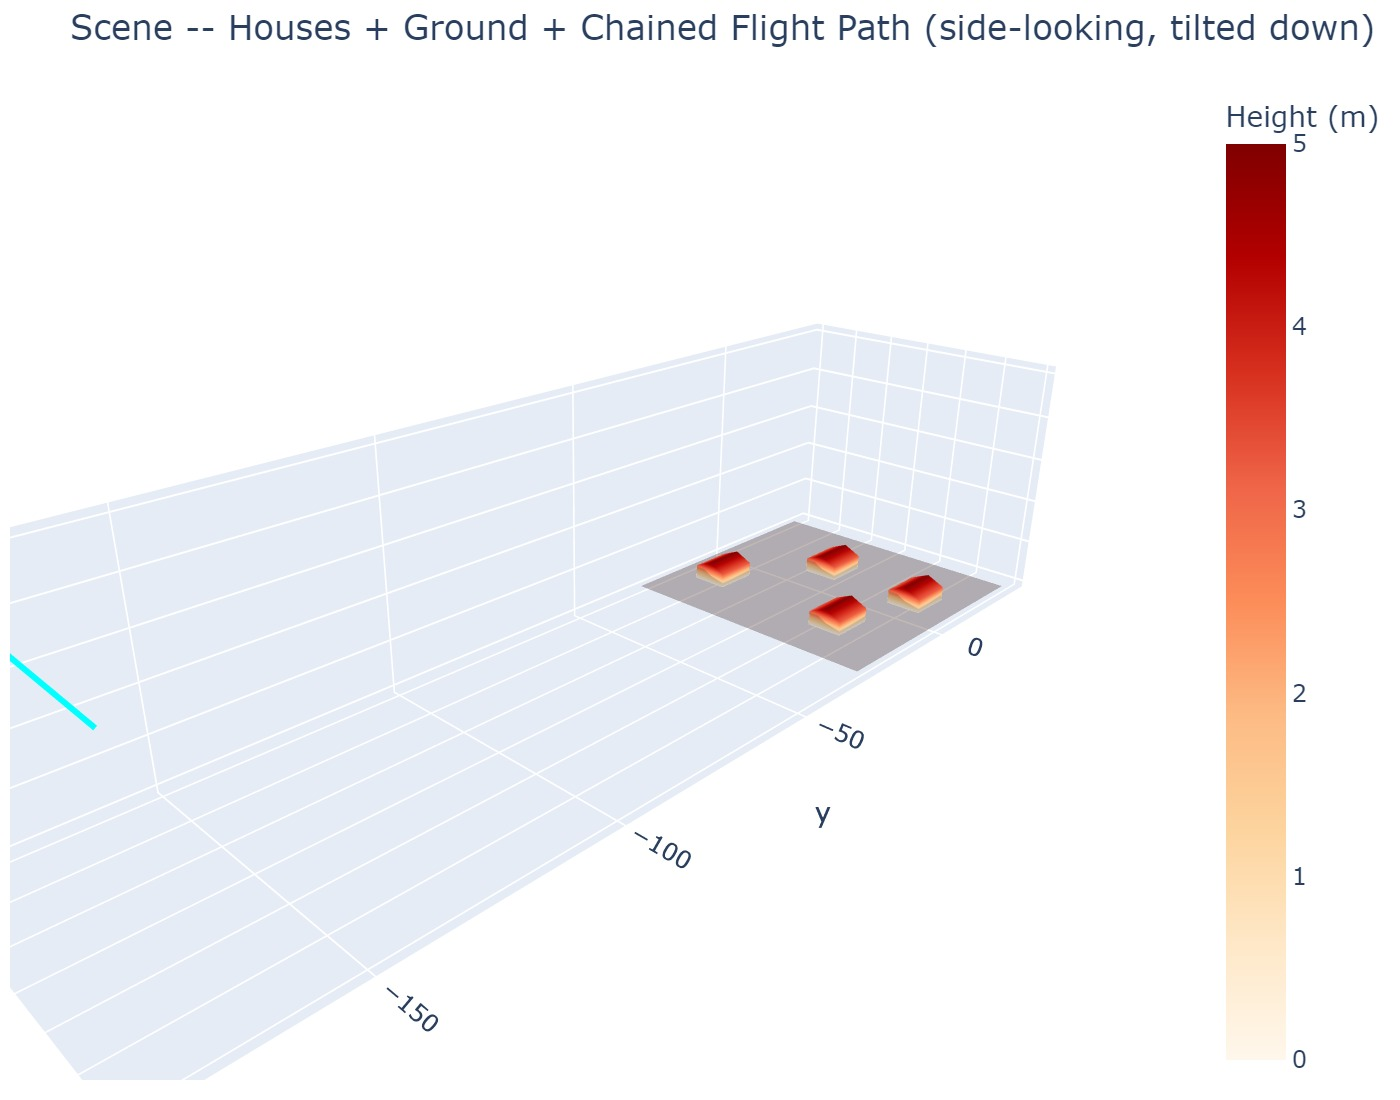

In [12]:
# -- 3D preview: real house.stl geometry replicated at each location, plus the flight path ----
ms_house = pymeshlab.MeshSet()
ms_house.load_new_mesh("../models/house.stl")
house_mesh = ms_house.current_mesh()
house_verts = np.array(house_mesh.vertex_matrix())
house_faces = np.array(house_mesh.face_matrix())

v_list, f_list = [], []
offset = 0
for hx, hy in house_positions:
    v_list.append(house_verts + np.array([hx, hy, 0.0]))
    f_list.append(house_faces + offset)
    offset += house_verts.shape[0]
v_vis = np.concatenate(v_list, axis=0)
f_vis = np.concatenate(f_list, axis=0)

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=[-30, 30, 30, -30], y=[-30, -30, 30, 30], z=[0, 0, 0, 0],
        i=[0, 0], j=[1, 2], k=[2, 3],
        color="#4E342E", opacity=0.35, name="Ground plane", showscale=False,
    )
)
fig.add_trace(
    go.Mesh3d(
        x=v_vis[:, 0], y=v_vis[:, 1], z=v_vis[:, 2],
        i=f_vis[:, 0], j=f_vis[:, 1], k=f_vis[:, 2],
        intensity=v_vis[:, 2], colorscale="OrRd",
        colorbar=dict(title="Height (m)"), name="Houses",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=platform_x,
        y=np.full_like(platform_x, y_fly),
        z=np.full_like(platform_x, z_fly),
        mode="lines",
        line=dict(color="cyan", width=6),
        name="Flight path",
    )
)

fig.update_layout(
    title="Scene -- Houses + Ground + Chained Flight Path (side-looking, tilted down)",
    scene=dict(aspectmode="data", camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0))),
    height=550,
    margin=dict(l=5, r=0, b=10, t=40),
)
show(fig)

## Simulation & SAR Processing

`sim_radar` ray-traces the LFM chirp against the ground plane and all four houses together. Because a single call is capped at 213 pulses (≈4.0 s of simulated flight at this scene's oversampled PRF), reaching the full ≈60 m flight means calling it `n_segments` = 3 times — once per segment, each with its own `radar.set_motion(...)` picking up exactly where the previous segment's platform position left off. Ray density is set much higher than in the terrain-notebook version (`density=1.0` vs `0.02`) — the scene here is only a handful of small meshes (16 faces per house, 2 for the ground plane), so a denser ray sample is cheap and meaningfully improves the fidelity of the houses' (mostly double-bounce) return. Thermal noise is added to each segment's baseband as before.

SAR processing has the same first stage as the point-target notebook, but a different second stage:

1. **Range Compression (Fast-Time FFT)** — run once per segment (immediately after that segment's `sim_radar` call), then concatenated into one combined range-compressed pulse train covering the whole chained flight.
2. **Sliding-Window Back-Projection** — instead of summing the *entire* flight for every pixel, each pixel is focused only from the pulses within its own real-beam footprint (a window that slides along with the along-track position), with a smooth raised-cosine taper across that local window. The two-way range still includes the fixed **vertical** term from the flat-earth reference:

$$R_n = \sqrt{(x_p-x_n)^2 + (y_p-y_{fly})^2 + (z_{ref}-z_{fly})^2}$$

BPA assumes every image pixel sits at the same flat reference elevation $z_{ref}$ — which, for the bare ground here, is exactly true. That mismatch only appears where the true scene height departs from $z_{ref}$: inside the four house footprints. That is exactly what produces relief displacement (layover) in the final image.

In [13]:
# -- Range compression setup: identical for every segment, computed once -------------
range_win = scipy.signal.windows.chebwin(pulse_samples, at=50)
NFFT = pulse_samples * 4  # zero-padding -> finer range grid
freq_axis = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1 / fs))
range_axis_full = freq_axis * c * tpd / (2 * bw)
range_window_lo, range_window_hi = R_near - 15, R_far + 15
range_mask = (range_axis_full >= range_window_lo) & (range_axis_full <= range_window_hi)
range_axis = range_axis_full[range_mask]

# -- Chain sim_radar calls: one per segment, each under the duration/pulse limits ----
# Each segment reuses the SAME radar object, just with a fresh set_motion(...) call
# continuing on from where the previous segment's platform positions left off.
t_offset = (num_pulses - 1) / 2 * prp
range_profile_list = []
tic_total = time.time()
for seg_idx, seg_center in enumerate(segment_centers):
    seg_locations = [seg_center + (radar.time_prop["timestamp"] - t_offset) * v_platform, y_fly, z_fly]
    radar.set_motion(location=seg_locations, rotation=[90, -dep_center, 0])

    tic = time.time()
    # density is much higher than the terrain-notebook version -- the scene here is
    # just a few small meshes (house.stl is 16 faces, the ground plane 2), so a much
    # denser ray sample is cheap and meaningfully improves the houses' RCS fidelity.
    data = sim_radar(radar, targets, density=1.0, level="pulse")
    # Add thermal noise -- without it the background is pure silence (0), which looks
    # artificially clean; real SAR imagery always has a speckled noise floor.
    baseband_seg = data["baseband"] + data["noise"]
    print(f"  segment {seg_idx+1}/{n_segments} (centre x={seg_center:.1f} m): "
          f"sim time {time.time()-tic:.0f} s")

    raw_seg = baseband_seg[0, :, :]
    range_profile_full_seg = np.fft.fftshift(
        np.fft.fft(raw_seg * range_win[np.newaxis, :], NFFT, axis=1), axes=1
    )
    range_profile_list.append(range_profile_full_seg[:, range_mask])

range_profile = np.concatenate(range_profile_list, axis=0)

print(f"All {n_segments} segments complete in {time.time()-tic_total:.0f} s total.")
print(f"  Combined range_profile shape: {range_profile.shape}  (num_pulses_total x range_bins)")
print(f"  Range axis: {range_axis[0]:.1f} to {range_axis[-1]:.1f} m")
print(f"  Range resolution after compression: {range_res:.3f} m")

  segment 1/3 (centre x=-20.0 m): sim time 212 s


  segment 2/3 (centre x=0.0 m): sim time 213 s


  segment 3/3 (centre x=20.0 m): sim time 231 s
All 3 segments complete in 656 s total.
  Combined range_profile shape: (639, 1668)  (num_pulses_total x range_bins)
  Range axis: 147.9 to 226.0 m
  Range resolution after compression: 0.187 m


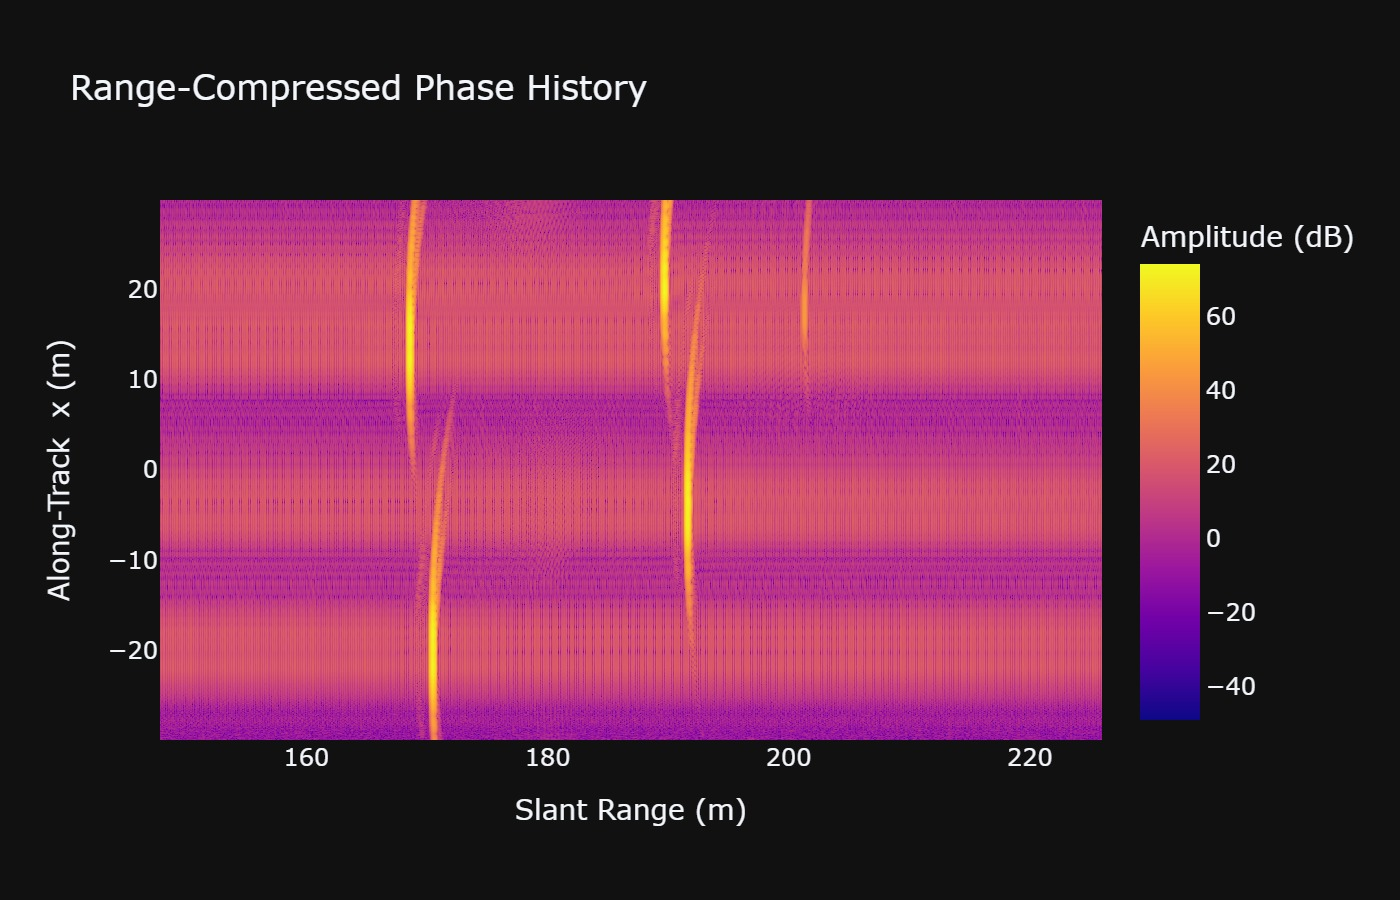

In [14]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=range_axis,
        y=platform_x,
        z=20 * np.log10(np.abs(range_profile) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Along-Track  x (m)",
    template="plotly_dark",
    height=450,
)
show(fig)

### Step 2: Sliding-Window Stripmap Focusing

For each pulse at along-track position $x_n$, only the image columns within $\pm$ half the real-beam footprint of $x_n$ can possibly see that pulse in reality, so only those columns receive its contribution. A **raised-cosine (Hann-shaped) taper**, continuous in distance rather than a fixed-length discrete window, smoothly rolls each pulse's contribution to zero at the edge of its footprint — this both controls azimuth sidelobes and avoids any hard cliff as pulses enter/exit a pixel's dwell.

This is the opposite computational trade-off from the earlier global-sum version: instead of iterating every pulse over the *entire* image (expensive, and it's what forced pulse count to scale with aperture²), each pulse now only touches a narrow local slice of the image — cheaper per pulse, and the achievable swath length no longer depends on how many pulses the license allows per call.

In [15]:
# -- Image grid ---------------------------------------------------------------
img_ranges = np.arange(y0, y1 + range_res, range_res)

half_footprint = footprint_length / 2
az_window = total_flight_length / 2 + half_footprint  # pixels just past the flight ends still get partial dwell
az_step = 0.5  # m -- kept close to az_res_stripmap; finer would be costly without adding real information
img_az = np.arange(cx - az_window, cx + az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az x {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_res:.3f} m)")

# -- Sliding-window stripmap Back-Projection ------------------------------------
# Each pulse only contributes to the image columns within its real-beam footprint
# (a window that slides with along-track position), weighted by a continuous
# raised-cosine taper -- NOT a global sum over the whole flight for every pixel.
# platform_x / range_profile now span ALL chained segments (num_pulses_total pulses).
dz_ref = z_fly - z_ref  # fixed vertical offset: flat-earth reference vs. flight altitude
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
tic_bpa = time.time()
for pulse_idx in range(num_pulses_total):
    x_n = platform_x[pulse_idx]

    # Image columns within this pulse's real-beam footprint
    lo = np.searchsorted(img_az, x_n - half_footprint, side="left")
    hi = np.searchsorted(img_az, x_n + half_footprint, side="right")
    if hi <= lo:
        continue
    az_local = img_az[lo:hi]

    # Continuous raised-cosine (Hann-shaped) taper vs. normalised distance from x_n
    u = (az_local - x_n) / half_footprint
    w_local = 0.5 * (1.0 + np.cos(np.pi * u))

    dx = az_local - x_n
    dy = img_ranges[:, np.newaxis] - y_fly
    R_n = np.sqrt(dx[np.newaxis, :] ** 2 + dy**2 + dz_ref**2)  # (n_ranges, n_local_az)

    interp_fn = interp1d(range_axis, range_profile[pulse_idx], kind="linear",
                          bounds_error=False, fill_value=0)
    interp_sig = interp_fn(R_n.ravel()).reshape(R_n.shape)
    phase_corr = np.exp(-1j * 4.0 * np.pi * R_n / lam)

    sar_image[lo:hi, :] += (w_local[np.newaxis, :] * interp_sig * phase_corr).T
toc_bpa = time.time()

print(f"Back-projection complete in {toc_bpa - tic_bpa:.0f} s.")
print(f"  SAR image shape : {sar_image.shape}  (Naz x Nr)")

Image grid: 159 az x 268 range pixels
  Azimuth : -39.3 to 39.7 m  (step 0.50 m)
  Range   : -25.0 to 25.0 m  (step 0.187 m)


Back-projection complete in 1 s.
  SAR image shape : (159, 268)  (Naz x Nr)


## Results: Focused SAR Image

The focused image (normalised power, dB) shows the bare ground as a dim, speckled background (its specular flat return mostly forward-scatters away from the radar at this depression angle) with four bright house returns standing out clearly. Unlike the point-target notebook, the houses are **not** at their true (x, y) ground position: Back-Projection assumed a flat reference elevation that's exact for the ground but wrong for anything standing on it, so each house is displaced in range. Every house here is *above* `z_ref`, so every one shifts toward the radar (shorter apparent range) — there's no "below-reference" case in this scene, unlike the earlier terrain version.

With the sliding-window fix and the chained ≈60 m flight (3 segments of ≈20 m each), the along-track (x) axis has much more room than any single `sim_radar` call could reach on its own. The layover check below validates the range-displacement physics quantitatively, using one house as a worked example.

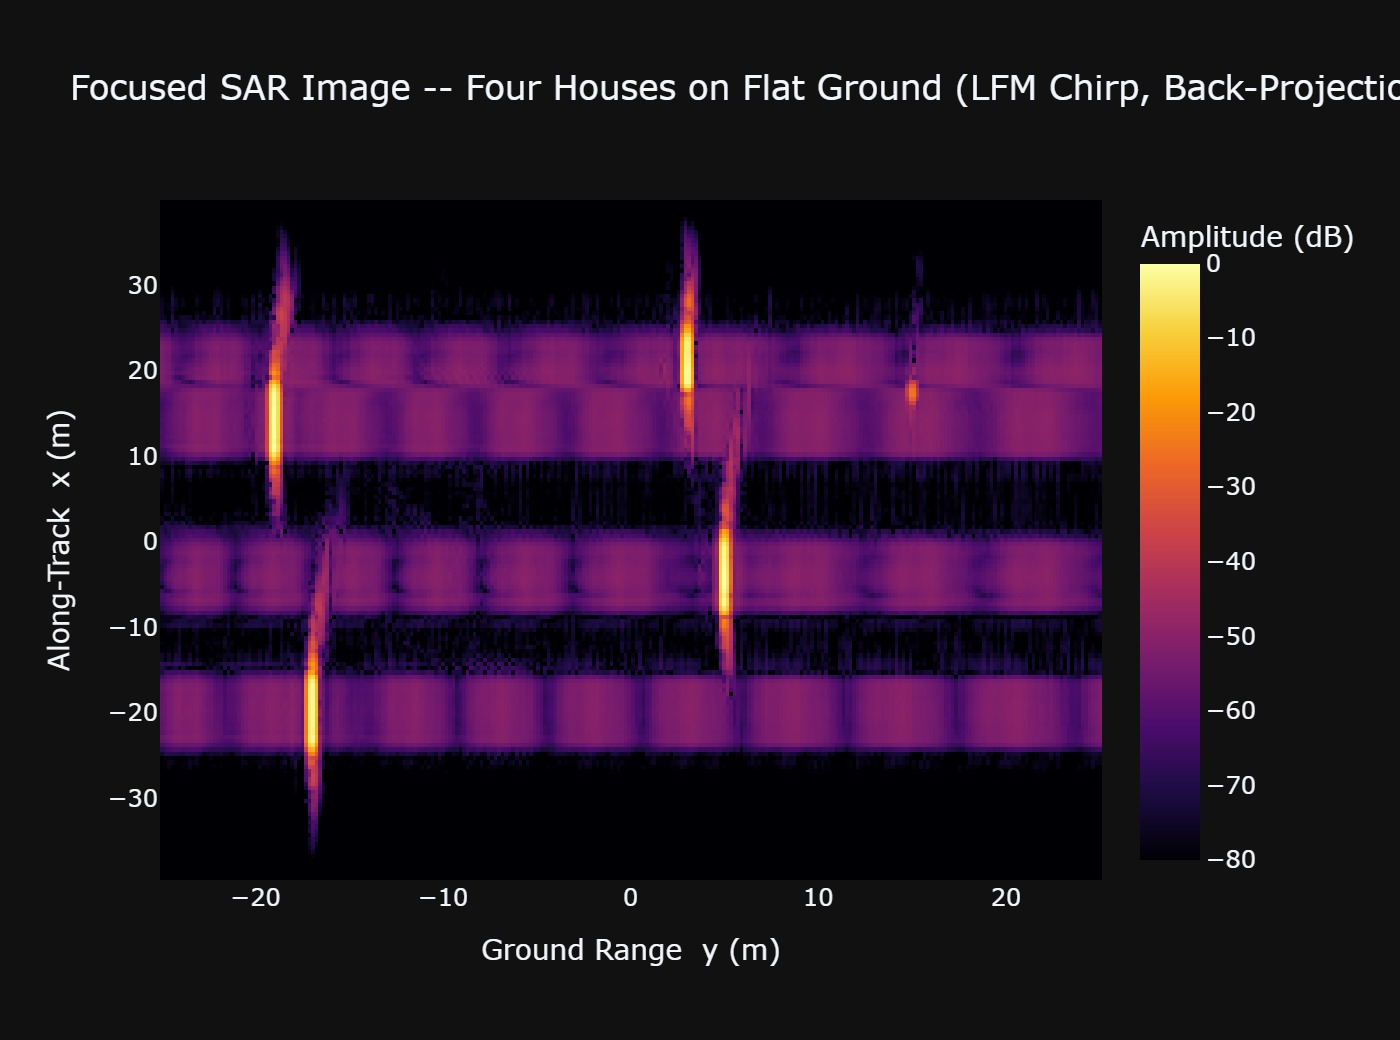

In [16]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()  # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges,
        y=img_az,
        z=sar_amp_db,
        colorscale="Inferno",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-80,
        zmax=0,
    )
)

fig.update_layout(
    title="Focused SAR Image -- Four Houses on Flat Ground (LFM Chirp, Back-Projection)",
    xaxis_title="Ground Range  y (m)",
    yaxis_title="Along-Track  x (m)",
    template="plotly_dark",
    height=520,
)
show(fig)

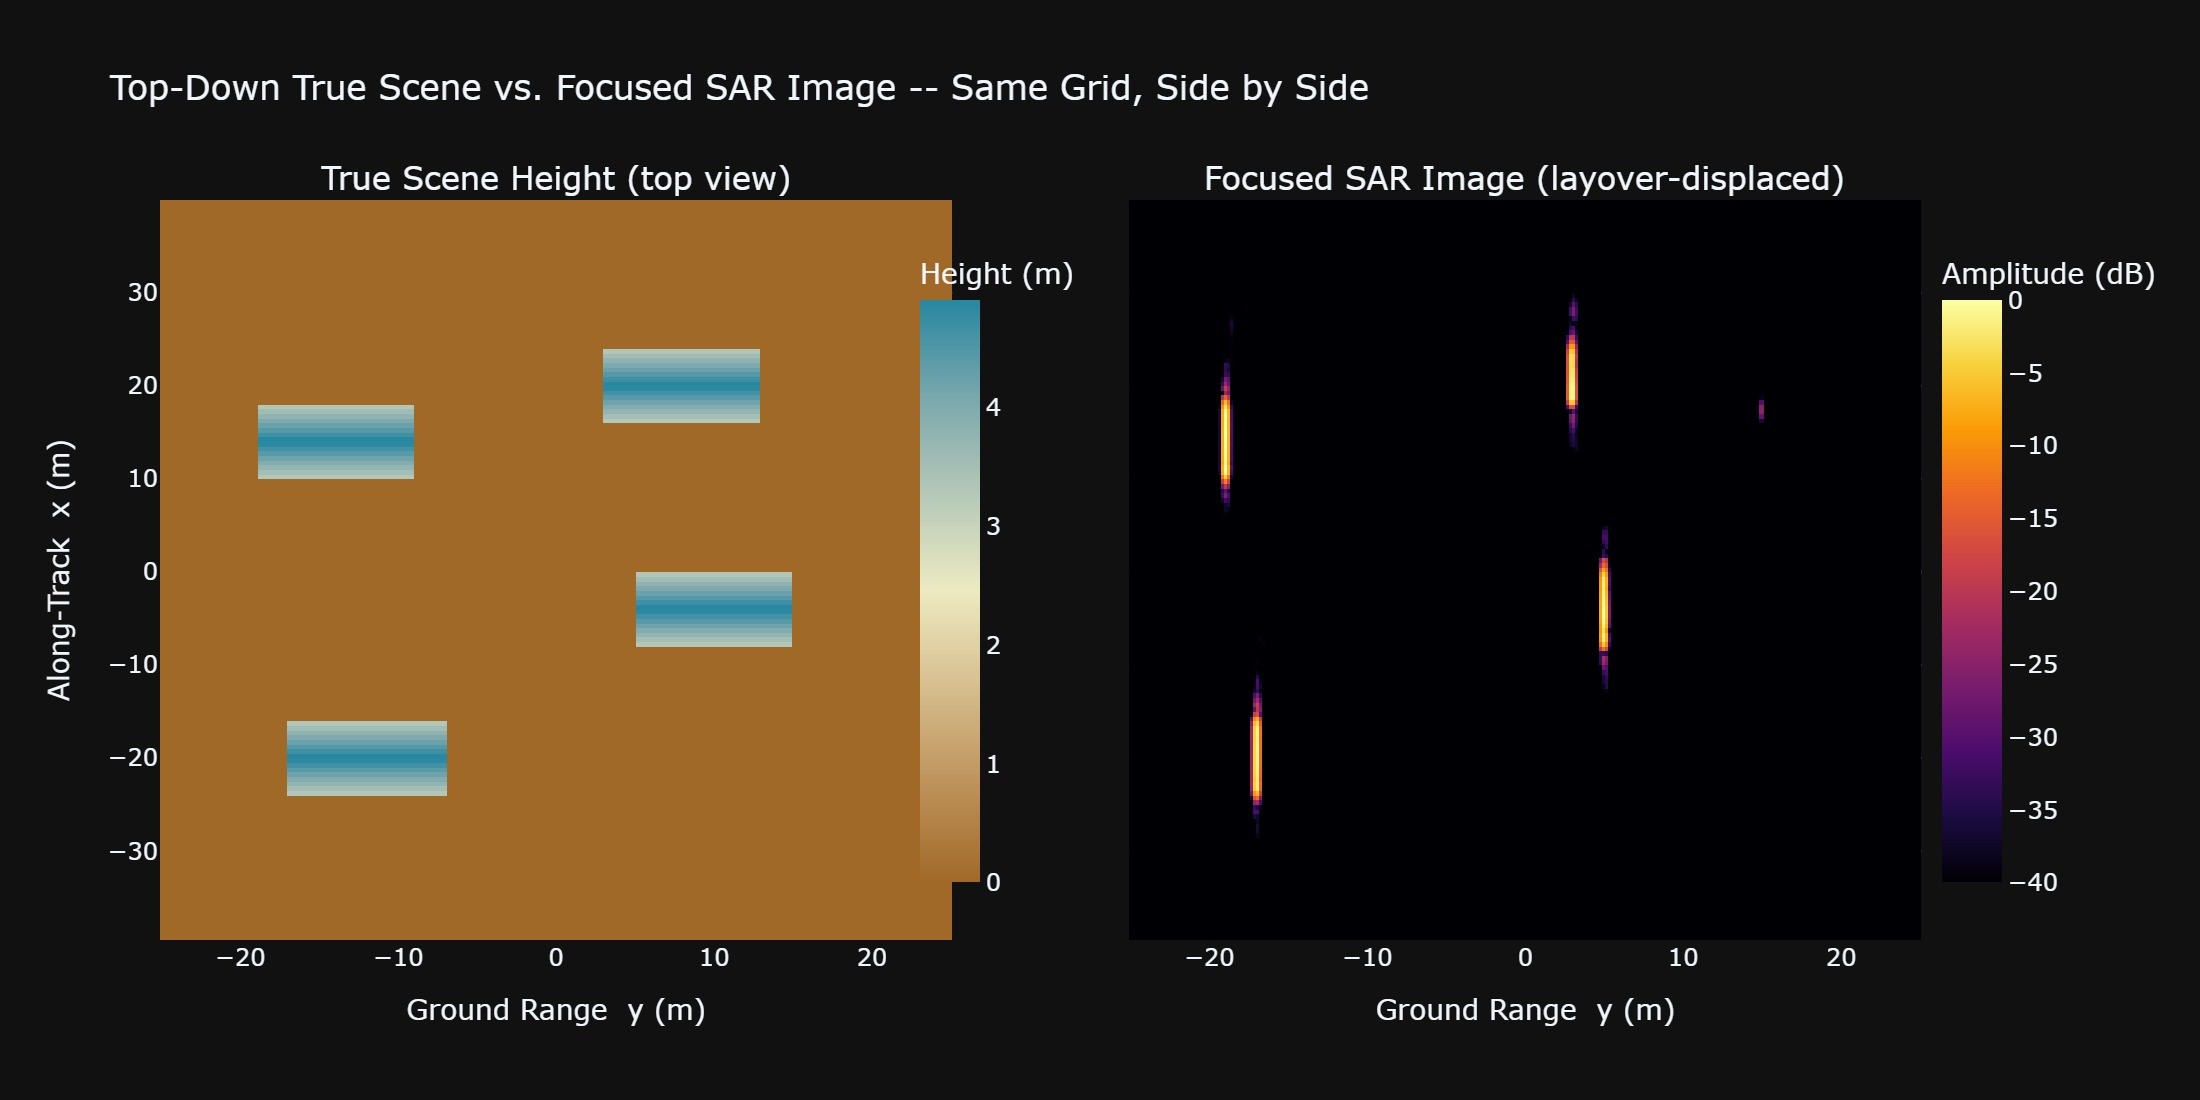

Both panels share the same (y, x) grid and orientation as the SAR image above.
Every house sits above z_ref, so each one shows up SHIFTED LEFT (shorter range)
in the right panel -- that shift IS the layover. The bare ground (height 0, exactly
equal to z_ref) is unaffected -- it focuses correctly, with no displacement at all.


In [17]:
# -- Top-down TRUE scene height, evaluated on the SAME grid as the SAR image ---------
# so the two can be compared pixel-for-pixel: same axes, same orientation, same extent.
# Because the scene is a simple analytic parametric model, no mesh sampling or
# interpolation is needed -- scene_height() is exact everywhere.
AZ, RNG = np.meshgrid(img_az, img_ranges, indexing="ij")
topo = scene_height(AZ, RNG)

fig = make_subplots(
    rows=1, cols=2, shared_yaxes=True,
    subplot_titles=("True Scene Height (top view)", "Focused SAR Image (layover-displaced)"),
    horizontal_spacing=0.1,
)
fig.add_trace(
    go.Heatmap(x=img_ranges, y=img_az, z=topo, colorscale="Earth",
               colorbar=dict(title="Height (m)", x=0.42, len=0.9)),
    row=1, col=1,
)
fig.add_trace(
    go.Heatmap(x=img_ranges, y=img_az, z=sar_amp_db, colorscale="Inferno",
               zmin=-40, zmax=0, colorbar=dict(title="Amplitude (dB)", x=1.0, len=0.9)),
    row=1, col=2,
)
fig.update_xaxes(title_text="Ground Range  y (m)", row=1, col=1)
fig.update_xaxes(title_text="Ground Range  y (m)", row=1, col=2)
fig.update_yaxes(title_text="Along-Track  x (m)", row=1, col=1)

fig.update_layout(
    title="Top-Down True Scene vs. Focused SAR Image -- Same Grid, Side by Side",
    template="plotly_dark",
    height=550,
    width=1100,
)
show(fig)

print("Both panels share the same (y, x) grid and orientation as the SAR image above.")
print("Every house sits above z_ref, so each one shows up SHIFTED LEFT (shorter range)")
print("in the right panel -- that shift IS the layover. The bare ground (height 0, exactly")
print("equal to z_ref) is unaffected -- it focuses correctly, with no displacement at all.")

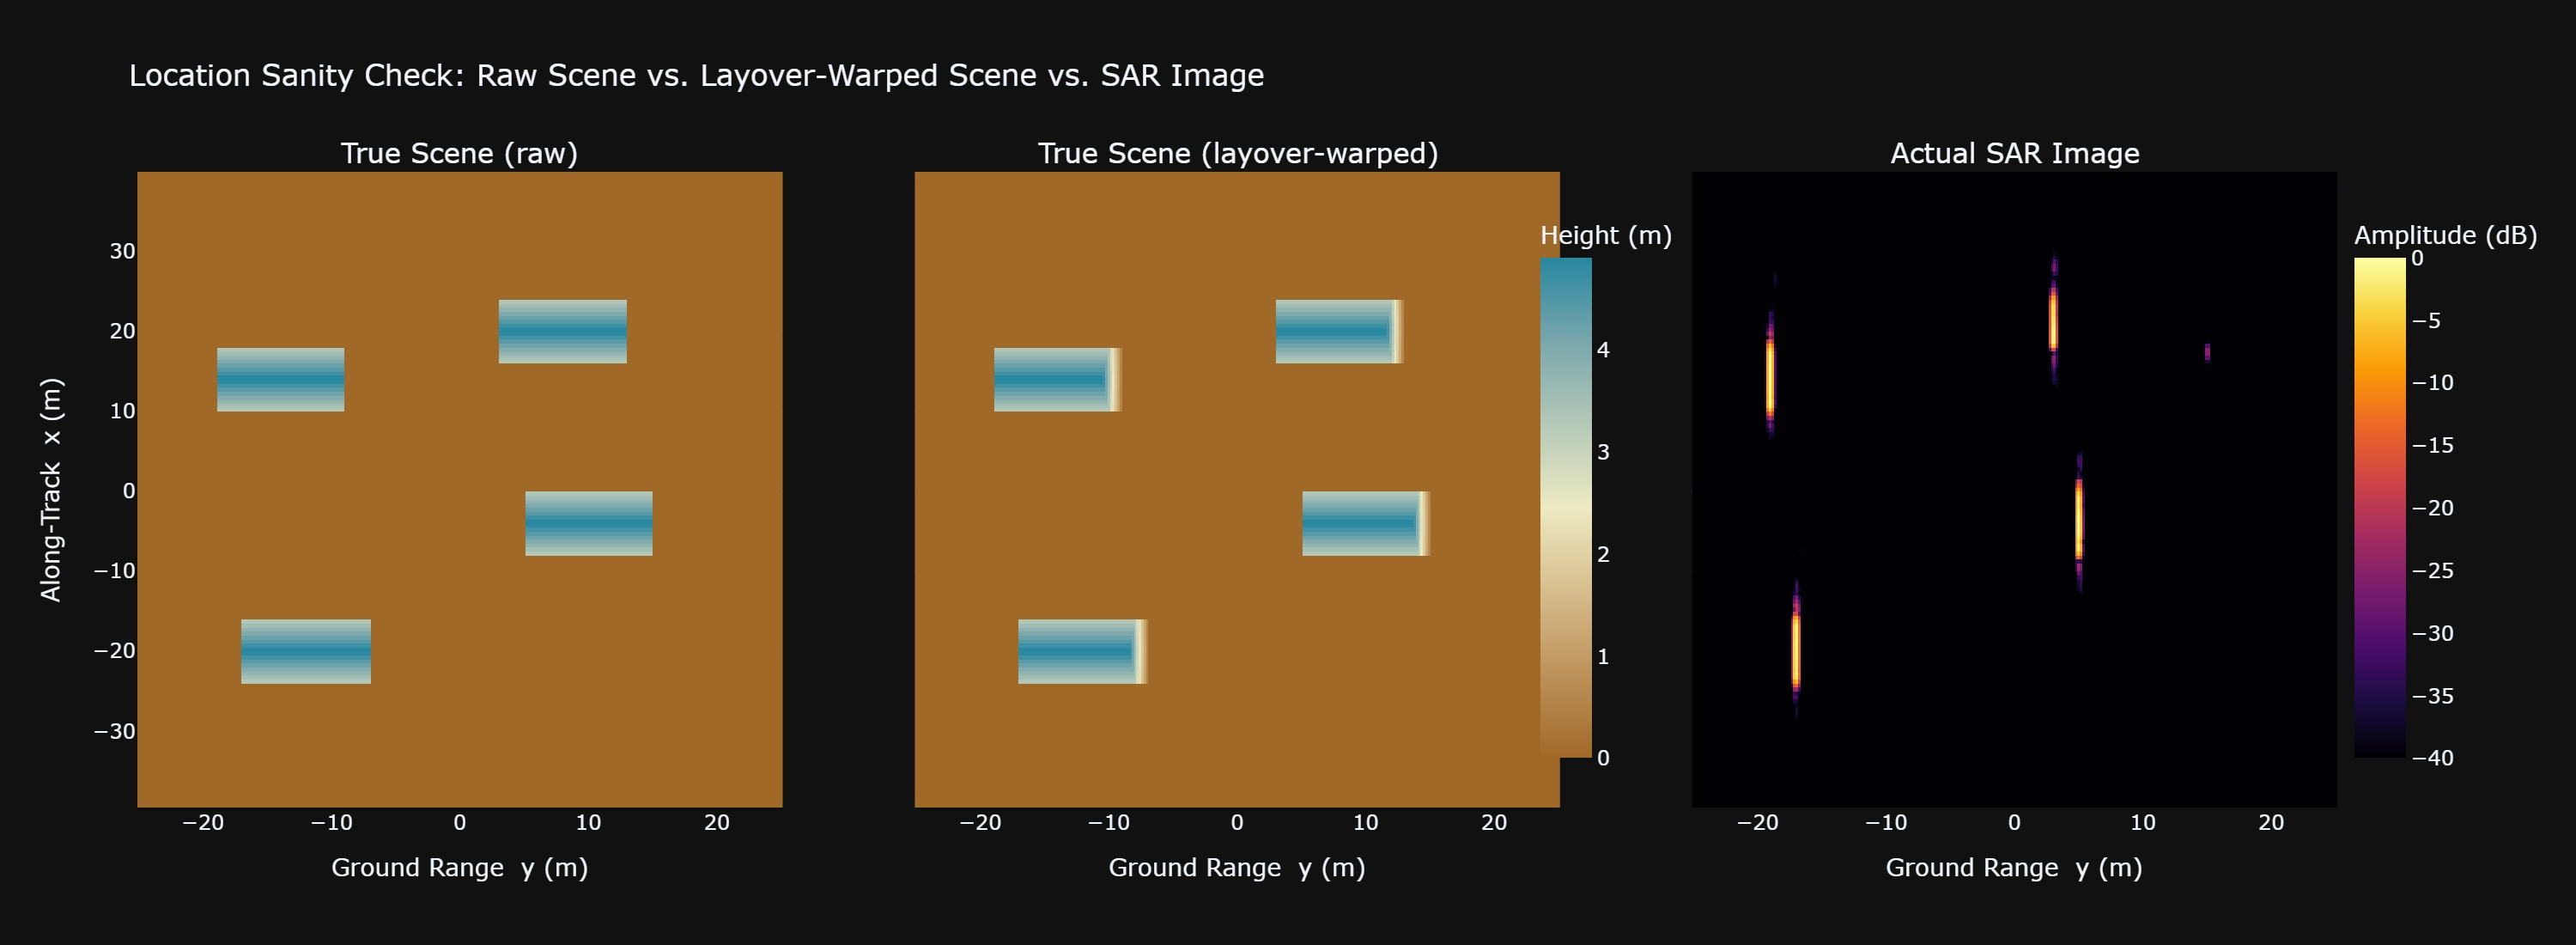

In [18]:
# -- Sanity check: is the SAR image actually looking at the right scene? --------------
# The raw top view (previous cell) and the SAR image are NOT expected to look alike --
# BPA displaces every off-z_ref point in RANGE (layover) before it ever reaches the
# image, and this sliding-window formula holds locally everywhere in the image (dx is
# always <= half_footprint from the pixel's own along-track position, since only nearby
# pulses contribute). So instead of comparing the RAW scene to the SAR image, warp every
# scene point through the SAME y_pred formula used in the layover check, then compare
# THAT to the actual SAR image. If location is correct, the warped map should resemble
# the SAR image much more closely than the raw one.
from scipy.interpolate import griddata

R_true_full = np.sqrt((RNG - y_fly) ** 2 + (z_fly - topo) ** 2)
y_pred_full = y_fly + np.sqrt(np.maximum(R_true_full**2 - dz_ref**2, 0))

# Re-grid the warped (AZ, y_pred_full, topo) point cloud back onto the regular image axes
topo_pred = griddata(
    (AZ.ravel(), y_pred_full.ravel()), topo.ravel(), (AZ, RNG), method="linear",
)

fig = make_subplots(
    rows=1, cols=3, shared_yaxes=True,
    subplot_titles=("True Scene (raw)", "True Scene (layover-warped)", "Actual SAR Image"),
    horizontal_spacing=0.06,
)
fig.add_trace(
    go.Heatmap(x=img_ranges, y=img_az, z=topo, colorscale="Earth", showscale=False),
    row=1, col=1,
)
fig.add_trace(
    go.Heatmap(x=img_ranges, y=img_az, z=topo_pred, colorscale="Earth",
               colorbar=dict(title="Height (m)", x=0.63, len=0.9)),
    row=1, col=2,
)
fig.add_trace(
    go.Heatmap(x=img_ranges, y=img_az, z=sar_amp_db, colorscale="Inferno",
               zmin=-40, zmax=0, colorbar=dict(title="Amplitude (dB)", x=1.0, len=0.9)),
    row=1, col=3,
)
for col in (1, 2, 3):
    fig.update_xaxes(title_text="Ground Range  y (m)", row=1, col=col)
fig.update_yaxes(title_text="Along-Track  x (m)", row=1, col=1)

fig.update_layout(
    title="Location Sanity Check: Raw Scene vs. Layover-Warped Scene vs. SAR Image",
    template="plotly_dark",
    height=550,
    width=1500,
)
show(fig)

## Layover Check: True Scene vs. Imaged Position

Because Back-Projection assumes every pixel sits at the flat reference elevation `z_ref`, a real point at true ground range $y_{true}$ and true elevation $z_{true}$ is not imaged at $y_{true}$ — it appears at

$$y_{pred} = y_{fly} + \sqrt{R_{true}^2 - (z_{ref}-z_{fly})^2}, \qquad R_{true} = \sqrt{(y_{true}-y_{fly})^2 + (z_{true}-z_{fly})^2}$$

We take one house as a worked example, slice the exact analytic scene height along that house's own along-track position, and compare each point's *predicted* image position against the actual bright bands in the focused SAR image.

In [19]:
# -- Sample the true scene height along one house's own along-track position ---------
house_idx = 2  # House 3, picked as the worked example (not at cx, to show this holds anywhere)
hx, hy = house_positions[house_idx]

y_true = np.linspace(y0, y1, 2001)
z_true = scene_height(np.full_like(y_true, hx), y_true)

R_true = np.sqrt((y_true - y_fly) ** 2 + (z_fly - z_true) ** 2)
y_pred = y_fly + np.sqrt(np.maximum(R_true**2 - dz_ref**2, 0))

# -- Actual SAR image cross-section through this house's along-track position --------
az_center_idx = np.argmin(np.abs(img_az - hx))
image_cut_db = 20 * np.log10(np.abs(sar_image[az_center_idx, :]) + 1e-12)
image_cut_db -= image_cut_db.max()

# -- Quantitative check: does the brightest imaged feature line up with the ---
# -- true scene point predicted to displace to that location? --------------
peaks, _ = find_peaks(image_cut_db, height=-25, distance=max(int(2 / range_res), 1))
peak_y = img_ranges[peaks]
peak_db = image_cut_db[peaks]
main_idx = np.argmax(peak_db)
nearest = np.argmin(np.abs(y_pred - peak_y[main_idx]))

print(f"Slicing through House {house_idx+1} at x={hx:+.1f} m, y={hy:+.1f} m")
print(f"Brightest imaged feature: y_p = {peak_y[main_idx]:.1f} m ({peak_db[main_idx]:.1f} dB)")
print(f"  Nearest true-scene match  : y_true = {y_true[nearest]:.1f} m, z_true = {z_true[nearest]:.1f} m")
print(f"  Predicted image position : y_pred = {y_pred[nearest]:.1f} m")
print(f"  Layover displacement      : {y_pred[nearest] - y_true[nearest]:+.1f} m "
      f"({'toward' if y_pred[nearest] < y_true[nearest] else 'away from'} the radar)")

Slicing through House 3 at x=+14.0 m, y=-14.0 m
Brightest imaged feature: y_p = -19.0 m (0.0 dB)
  Nearest true-scene match  : y_true = -17.5 m, z_true = 5.0 m
  Predicted image position : y_pred = -19.0 m
  Layover displacement      : -1.5 m (toward the radar)


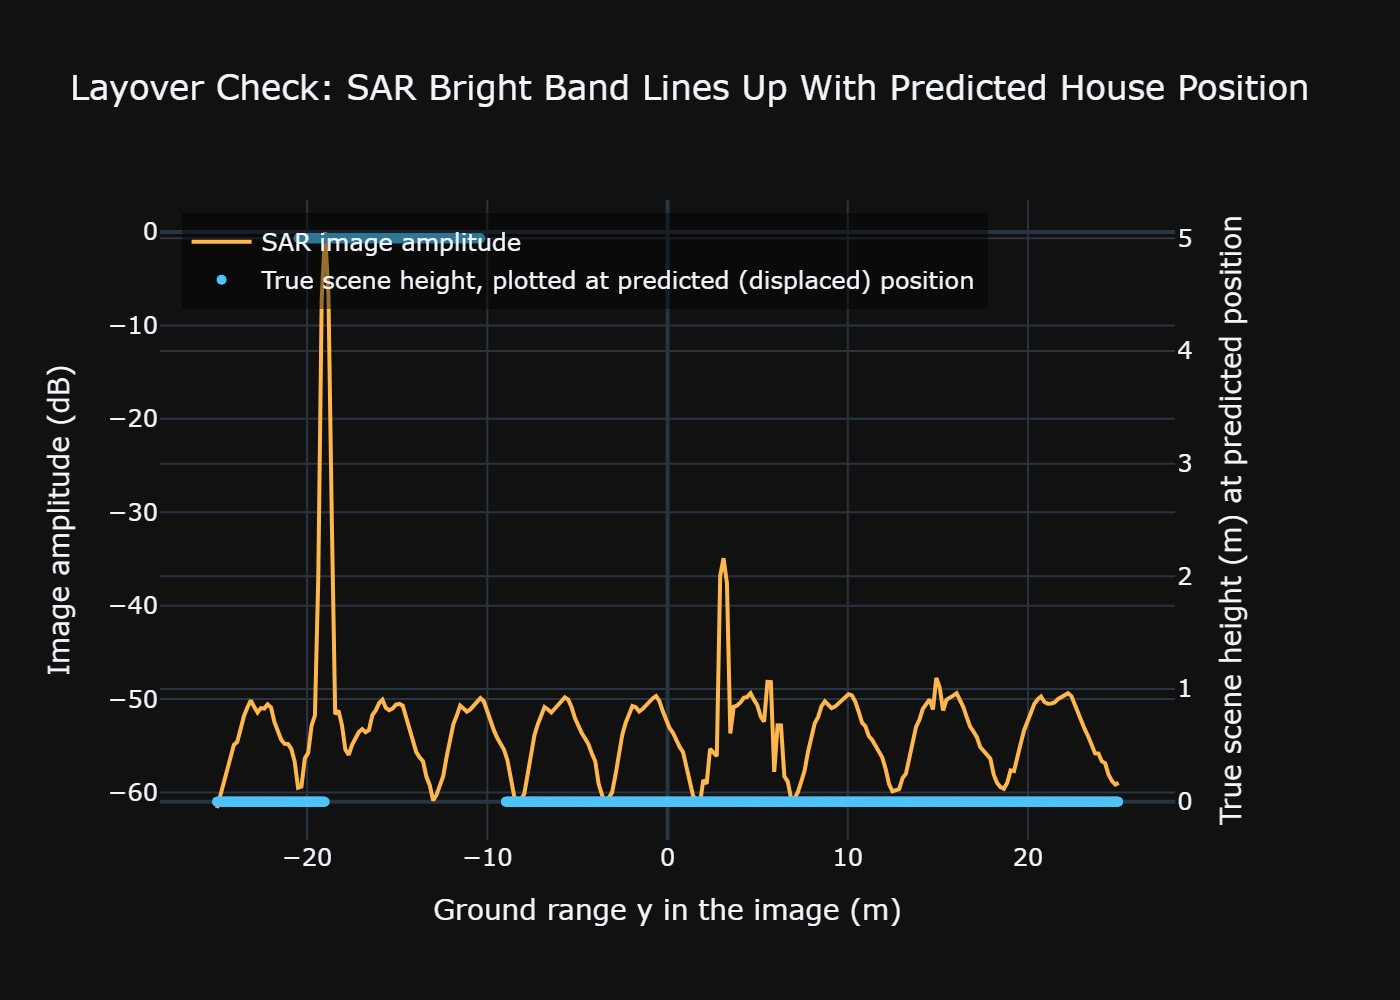

In [20]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=img_ranges, y=image_cut_db, name="SAR image amplitude",
        line=dict(color="#FFB74D", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=y_pred, y=z_true, name="True scene height, plotted at predicted (displaced) position",
        mode="markers", marker=dict(color="#4FC3F7", size=5),
    ),
    secondary_y=True,
)
fig.update_xaxes(title_text="Ground range y in the image (m)")
fig.update_yaxes(title_text="Image amplitude (dB)", secondary_y=False)
fig.update_yaxes(title_text="True scene height (m) at predicted position", secondary_y=True)
fig.update_layout(
    title="Layover Check: SAR Bright Band Lines Up With Predicted House Position",
    template="plotly_dark",
    height=500,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(0,0,0,0.4)"),
)
show(fig)

## Summary

This notebook extended the C-band stripmap LFM SAR simulation from `waveform_lfm_sar.ipynb` to a **small synthetic scene** — four houses on flat ground — instead of idealized point targets or natural terrain:

| Stage | Key Parameters | Result |
|---|---|---|
| Scene | 4 x `house.stl` (8x10 m footprint, 5.0 m ridge) + `surface_60x60.stl` ground | A close-in neighborhood-scale scene, tens of meters across |
| Waveform | $f_c$=4 GHz, B=800 MHz, τ=2 μs | ΔR=0.187 m; short pulse keeps `fs` around 1.3 GHz given the ~160-210 m slant range |
| Flight geometry | v=5 m/s (survey UAS), 3 segments x 213 pulses, alt=50 m, standoff 180 m | ≈60 m chained flight (PRF≈53.3 Hz, 4x Nyquist oversampling, each segment duration-capped at 4.0 s); shallow ≈14-18° depression angle |
| Radar hardware | narrow azimuth (0.75 m antenna, cos^277 pattern derived to actually hit that beamwidth, ±15°), wide elevation (cos³, ±20°) | beamwidths matched to the real illumination geometry |
| Simulation | ground plane + 4 houses ray-traced 3x, `density=1.0`, thermal noise added each segment | ground plane's specular return stays dim; houses' wall-ground double bounce stands out |
| Range compression | fast-time FFT, Chebyshev window, per segment then concatenated | ΔR=0.187 m |
| Image formation | **sliding-window stripmap BPA** over the combined pulse train + flat `z_ref`=0 m (exact ground truth) | reveals four houses — **all displaced by layover** — across a flight 3x longer than one `sim_radar` call could reach |
| Validation | exact analytic scene height vs. predicted image position, plus a full-image layover-warp comparison | bright house returns match the predicted layover position |

### Houses SAR vs. the Point-Target Notebook

The point-target notebook's Back-Projection focuses perfectly because every target really does sit at $z=0$, matching the flat reference the algorithm assumes. This scene makes that assumption exact for the *ground* (`z_ref` = 0, the scene's true elevation) — yet layover still appears, because the **houses** rise above it. A house rising 5 m above the reference elevation returns its energy at a *shorter* range than a ground pixel at the same map coordinate would, so BPA places it too close to the radar. This is **relief displacement (layover)** — a real, well-documented artifact in airborne and spaceborne SAR imagery of any scene with 3-D structure, buildings very much included, and true ortho-rectification requires knowing the actual scene height, not a single flat reference.

### Five Fixes to Get Here

Earlier passes through this notebook family summed the *entire* flight as one synthetic aperture for every pixel (spotlight-style), which forces pulse count to scale with the *square* of the aperture length. **Sliding-window stripmap focusing** fixed that — each pixel is focused only from the pulses inside its own real-beam footprint, decoupling flight length from the aperture-squared penalty.

That surfaced a second problem: this evaluation build of `sim_radar` **silently stops updating platform motion after ≈5.0 s** of simulated time, quietly re-returning stale, bit-for-bit identical data instead of erroring. The fix was to cap each `sim_radar` call's duration at 4.0 s.

Neither limit — pulse count nor duration — is about *total* flight length, though; they're both per-call. So this version **chains three `sim_radar` calls**, each independently safe (213 pulses, ≈4.0 s), with each segment's `radar.set_motion(...)` picking up exactly where the previous one's platform positions left off. The range-compressed results are concatenated into one combined pulse train and back-projected together, reaching ≈60 m total — 3x what any single call could produce, without touching either limit.

A fourth fix was the antenna pattern itself: the azimuth `cos^n` exponent has to be derived (not guessed) so its *actual* -3 dB angle matches the physical beamwidth (`lam/Da`) the BPA math assumes — an exponent that's too gentle lets the antenna "see" a target across almost the whole flight, and the sliding-window formula then smears that target's real echo across a wide arc of the image instead of focusing it locally.

The fifth, and the one that took the most digging: **depression angle controls whether the houses are visible at all, not just how cleanly they layover.** A flat-faced box-with-a-roof model scatters via specular reflection, which is only strong in a narrow set of directions, and for simple buildings on flat ground the dominant real return is a **wall-ground double bounce** — strongest at shallow depression angles and rapidly weaker past ~25°. The standoff here was chosen to sit in that shallow, double-bounce-favorable regime; a steeper, more "aircraft-like" depression (which felt more natural at first) left the houses buried in the noise floor.

### Things to Try

| Experiment | How | Observable effect |
|---|---|---|
| Remove layover | Look up the true height per-pixel from `scene_height()` instead of a constant `z_ref` | Layover-corrected ("ortho-rectified") image, sharp house outlines |
| Add more houses / vary height | Extend `house_positions`, or make `HOUSE_HW`/`HOUSE_HR` vary per instance | Taller houses layover further; more houses fill the swath |
| Steeper depression | Reduce the standoff (`y0 - y_fly`) | Houses fade fast past ~25° depression -- a direct look at the double-bounce falloff |
| Even higher resolution | Increase `bw` further (range) or shrink `Da` further (azimuth) | Finer ΔR / Δaz, at the cost of higher `fs`/pulse count and runtime |
| Even wider swath | Increase `n_segments` further | Longer flight, proportionally longer runtime |
| Higher fidelity | Increase `density` further (accepting a longer runtime) | Less speckled house/ground return, better facet-level detail |
| More looks per pixel | Increase `prf_margin` further | Smoother speckle / lower azimuth sidelobes, without changing the Dₐ/2 resolution floor |